Comparing performance of ML approaches for activity classification.... in other words, mutli-class classification model with different algorithms comparing the performance w/ each algorithm.

-> Makes sense, 11:51 min video w/ 100 samples per sec... so hence we expect approx. 71100 samples/lines of data & note that we are not required to use VOTT or any other annotation/tagging tool
   as we are already provided with the ```a3_activity_annotations.csv``` which has already done this.

-> Classes: Walking, Standing, Jogging, Side-step (4 ttl classes)

-> ```imu data columns: timestamp, x-axis acceleration, y-axis acceleration, z-axis acceleration, x-axis gyro, y-axis gyro, z-axis gyro``` (acceleration and gyroscope values are reported in arbitrary units (16-bit signed values) which represent a range of +/- 8g for the accelerometer and +/- 8000dps (degrees-per-second) for the gyroscope.)

### Steps:
  - Align and combine a dataset captured from an inertial sensor with an activity annotation file produced from a video recording of the data capture session.
  - Visualize the combined dataset to check that the data has been correctly imported into Python and aligned with activity transitions.
  - Process the activity annotation data to assign a target activity to each data point within the IMU dataset.
  - Calculate a set of features from the raw sensor data.
  - Apply a machine learning workflow to test a selection of classification algorithms on the feature set for the task of activity classification.
  - Perform hyper-parameter optimization on at least one parameter for each algorithm.
  - Create some visualizations and report on the model that your machine learning approaches have learned from the data.


### Steps 1 & 2:

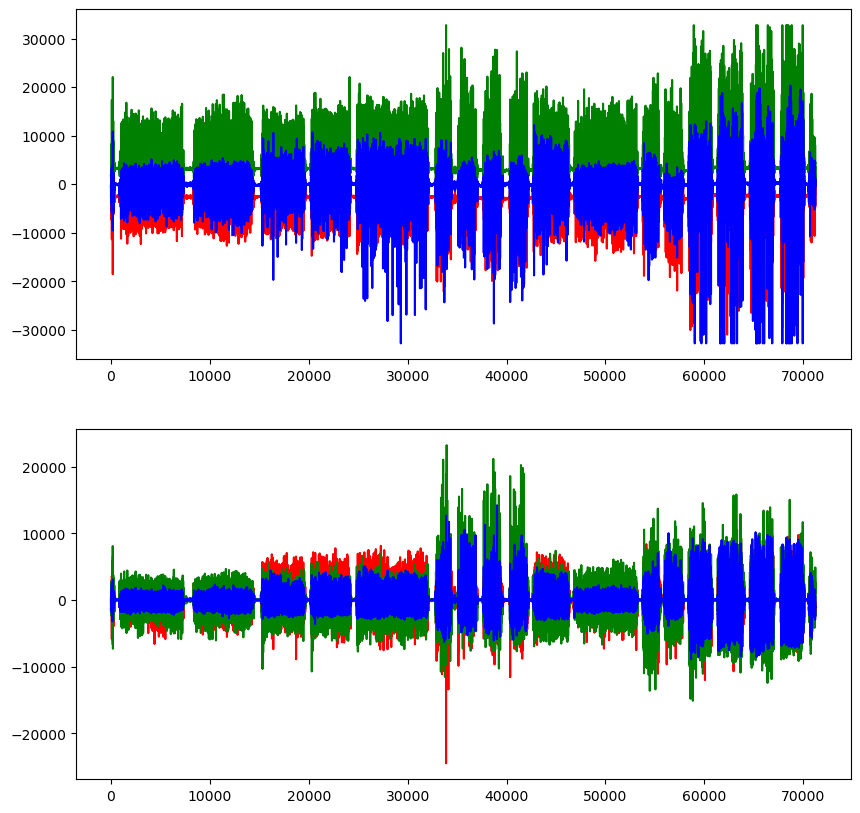

In [274]:
import csv
import matplotlib.pyplot as plt
import statistics
import math
import numpy as np

# lists to store IMU data:

# epoch timestamps for each reading
time_track = []

# Accelerometer data:
x_axis_acceleration_data = []
y_axis_acceleration_data = []
z_axis_acceleration_data = []

# Gyrometer data:
x_axis_gyro = []
y_axis_gyro = []
z_axis_gyro = []

activity_label = []

def map_activity(activity_string):
    if activity_string == 'Standing':
        return 0
    elif activity_string == 'Walking':
        return 1
    elif activity_string == 'Side-Step':
        return 2
    elif activity_string == 'Running':
        return 3
    elif activity_string == 'Jogging':
        return 4
    
with open('a3_imu_data.csv',newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        time_track.append(float(row[0]))
        x_axis_acceleration_data.append(float(row[1]))
        y_axis_acceleration_data.append(float(row[2]))
        z_axis_acceleration_data.append(float(row[3]))
        x_axis_gyro.append(float(row[4]))
        y_axis_gyro.append(float(row[5]))
        z_axis_gyro.append(float(row[6]))
        
fig,ax = plt.subplots(2,1,figsize=(10,10))
ax[0].plot(x_axis_acceleration_data, color='r')
ax[0].plot(y_axis_acceleration_data, color='g')
ax[0].plot(z_axis_acceleration_data, color='b')

ax[1].plot(x_axis_gyro, color='r')
ax[1].plot(y_axis_gyro, color='g')
ax[1].plot(z_axis_gyro, color='b')

In [275]:
print(len(time_track)) #check if match 71.1k estimate....
print(time_track[:20]) # just to see whats up here...
print(time_track[0]) #first timestamp
print(time_track[-1]) #last timestamp
print(time_track[-1] - time_track[0]) #total duration in secs, compare to 711

71242
[1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0]
1598240213.0
1598240943.0
730.0


Ok so we have 71,242 so a bit of excess data we need to chop off...
and 730 is more than 711... so we have like 19sec of data we need to chop off i.e. where the data from the IMU was being logged, but the video was not recording.... also note that 71242/730.0 = 97.59 (so on avg 97.59 samples per sec... not exactly 100)

So somewhere within the dataset file, there is approx 19 sec worth of rows (~1900 since 100 samples per sec) that fall outside vid, either before start, after end or split between the two... we now need to find when...

Well we know vid starts w/ walking & ends with like a running then finally standing at the very end.... 

So now Looking @ the very beginning & end visually:

Text(0.5, 1.0, 'Last 3000 samples ~ 30 sec')

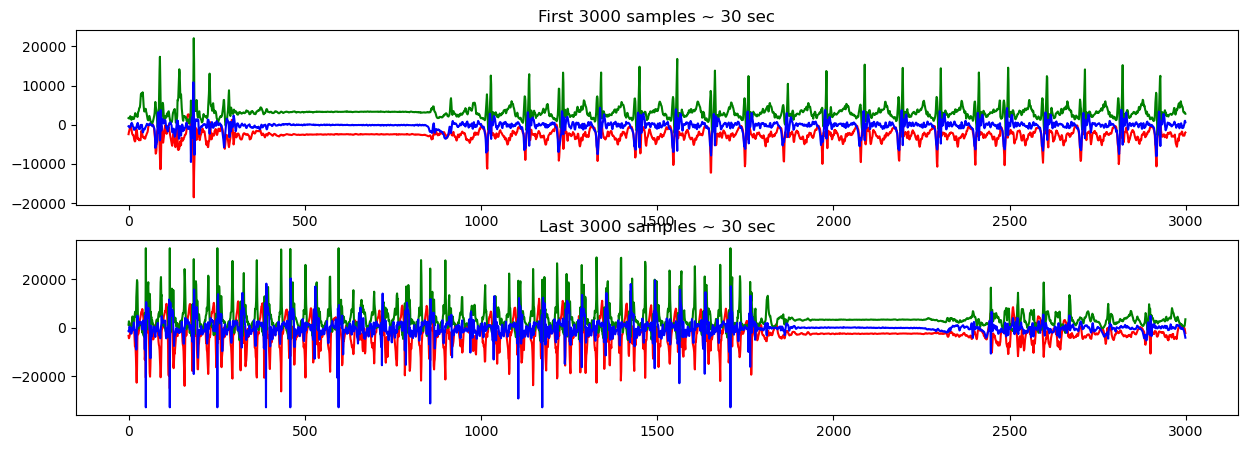

In [276]:
fig,ax = plt.subplots(2, 1, figsize=(15,5))

ax[0].plot(x_axis_acceleration_data[0:3000], color='r')
ax[0].plot(y_axis_acceleration_data[0:3000], color='g')
ax[0].plot(z_axis_acceleration_data[0:3000], color='b')
ax[0].set_title("First 3000 samples ~ 30 sec")

ax[1].plot(x_axis_acceleration_data[-3000:], color='r')
ax[1].plot(y_axis_acceleration_data[-3000:], color='g')
ax[1].plot(z_axis_acceleration_data[-3000:], color='b')
ax[1].set_title("Last 3000 samples ~ 30 sec")

Hmm we know that the video starts with walking... so we can't look for a flat line for like standing to easily chop off the excess seconds, instead we can just try and use the durations we already have in the annotation file as a fingerprint to search for (as they're precise & numeric):

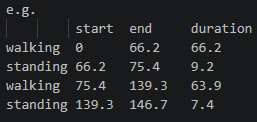

so that 9.2 standing gap is best chance.... so if our recording for IMU started close to when vid did then that standing dip part should come close to the 60-90 sec mark.... so let's zoom in on that:

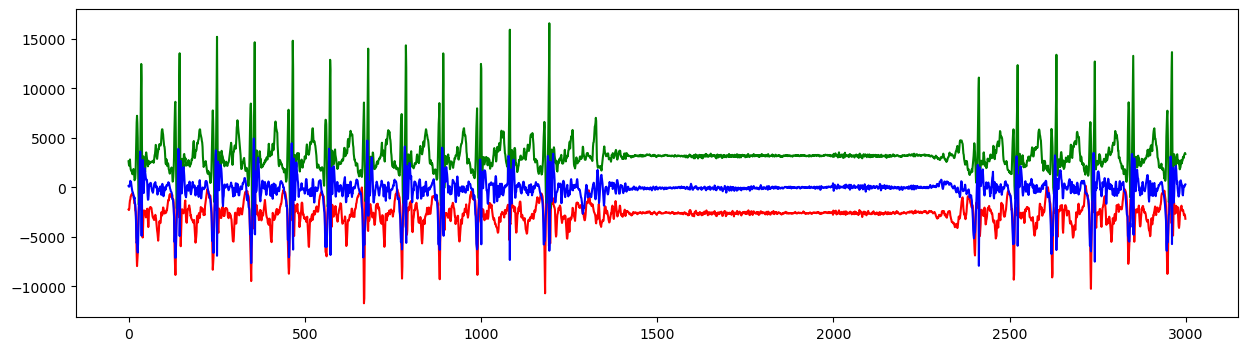

In [277]:
focused_section_start = 6000 # as 60 sec = 60*100 samples
focused_section_end = 9000 # same story, 90 sec = 90 * 100

fig,ax = plt.subplots(figsize=(15,4))
ax.plot(x_axis_acceleration_data[focused_section_start:focused_section_end], color='r')
ax.plot(y_axis_acceleration_data[focused_section_start:focused_section_end], color='g')
ax.plot(z_axis_acceleration_data[focused_section_start:focused_section_end], color='b')

inshallah...hehehe SIUUUU

so it seems like ~1350-1400 sample mark should be when the standing part starts, i.e. at 66.2 sec in the video.... so now we can work backwards. Look @ it it's perfect.. it lasts around like 920-950 samples as we'd expect...

so the standing start index is like 1400 + 6000 = 7400:

In [278]:
standing_start_index = 7300

standing_start_timestamp = time_track[standing_start_index]
print(standing_start_timestamp)

1598240287.0


So this ^ is the timestamp from the csv which the standing begings i.e. at 66.2 sec

In [279]:
video_start_timestamp = standing_start_timestamp - 66.2
# puta madre, our time_track is storing whole secs never fractions.... & throwing fractions gives
# e.g. Value Error: 1598240221.8 is not in list... so let's just round best we can do:
# ahh u know what instead of doing this all the time:
# video_start_index = time_track.index(int(round(video_start_timestamp)))
# let's create a function for it... kills two birs w one stone, saves time + rubrics reusable functions..

def find_index_for_timestamp(curr_timestamp:float,time_track:list[float])-> int:
    '''
        TODO: Docstring
    '''
    return time_track.index(int(round(curr_timestamp)))

video_start_index = find_index_for_timestamp(video_start_timestamp,time_track)

print("Video starts @ timestamp: %s" %video_start_timestamp)
print("Video start index (si senor, w/ some rounding): %s " %video_start_index)

Video starts @ timestamp: 1598240220.8
Video start index (si senor, w/ some rounding): 800 


we know our vid is 711 sec.... so the end calculation should be easy:
- end_index = time_track.index(video_start_timestamp+711)

but let's just double check with one more set of points & our start index to make sure we are accurate:

Let's run it on the standing gap between 139.333 & 146.7333 & using our ```video_start_timestamp```:


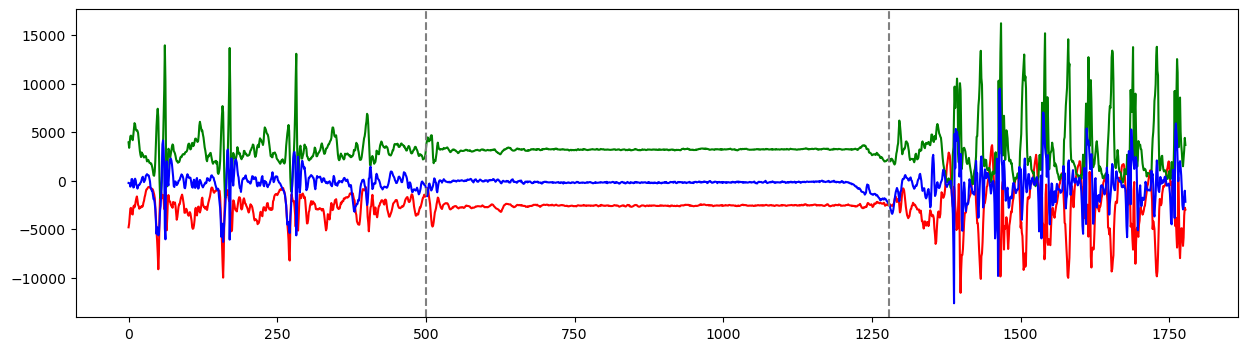

In [280]:
focused_section2_start = find_index_for_timestamp(video_start_timestamp + 139.333,time_track) 
focused_section2_end = find_index_for_timestamp(video_start_timestamp + 146.733,time_track)
window_len = focused_section2_end - focused_section2_start

pad=500
fig,ax = plt.subplots(figsize=(15,4))
ax.plot(x_axis_acceleration_data[focused_section2_start-pad:focused_section2_end+pad], color='r')
ax.plot(y_axis_acceleration_data[focused_section2_start-pad:focused_section2_end+pad], color='g')
ax.plot(z_axis_acceleration_data[focused_section2_start-pad:focused_section2_end+pad], color='b')
ax.axvline(pad, color='gray', linestyle='--') # marks where window thinks it starts
ax.axvline(pad + (focused_section2_end-focused_section2_start), color='gray', linestyle='--') # marks where window thinks it ends

index 7300 from above performs better than 7400... so i think i'll settle w/7300...

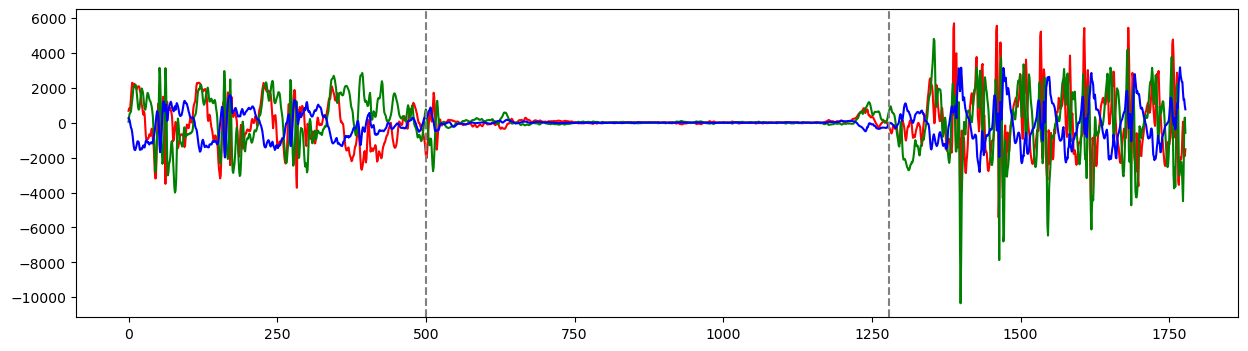

In [281]:
focused_section2_start = find_index_for_timestamp(video_start_timestamp + 139.333,time_track) 
focused_section2_end = find_index_for_timestamp(video_start_timestamp + 146.733,time_track)
window_len = focused_section2_end - focused_section2_start

pad=500
fig,ax = plt.subplots(figsize=(15,4))
ax.plot(x_axis_gyro[focused_section2_start-pad:focused_section2_end+pad], color='r')
ax.plot(y_axis_gyro[focused_section2_start-pad:focused_section2_end+pad], color='g')
ax.plot(z_axis_gyro[focused_section2_start-pad:focused_section2_end+pad], color='b')
ax.axvline(pad, color='gray', linestyle='--') # marks where window thinks it starts
ax.axvline(pad + (focused_section2_end-focused_section2_start), color='gray', linestyle='--')

how i got to this thought:
searched: how to detect when a person stops moving IMU sensors

got to https://electronics.stackexchange.com/questions/700696/how-to-detect-trajectory-of-an-object-using-imu-sensor-data

person mentioned Kalman filter....

Kalman filter wiki: https://en.wikipedia.org/wiki/Kalman_filter


But important thing here... this time indexing is the entire thing which our ML models are based off here... so we have to get it pretty accurate. There is a way we can get the computer to calculate instead of just looking & guessing the right thing.... at a certain point in time we look at variance around a buffer zone... i.e. when a person is coming to a stop.. they're variance must be decreasing right... so we'd get like a somewhat steep downward trending hill and then a flat line.... & when a person resumes activity from coming to a stop, their variance will be increasing, so we get somewhat a steep upward hill... we can't really just measure this directly at one particular point... so we study the movement within a certain localised zone of approx 50 samples lets say... If we are able to workout the variance over the localised buffer zone and it is below some threshold we determine to classify an object as stationary or in motion, then the person within that localed buffer zone is stationary we say & vice versa for moving. So there is a calculation throughout the whole period of movement recorded from the sensor to track the points which are determined to be stationary... & this should return a "better" approximation which is calculated rather than having one person look & say it's 7300 and another person look & say 7400.... hopefully at least... so say no to one point and say yes to like calculating the variance of every point within the localised buffer zone & threshold the entire array containing all the variances.. But i think another thing to note here is that the detector not looking at an upward/down hill, just within the local buffer zone, how much does the sensor singal change.... & also low variance doesn't mean standing as they could have dropped the sensor or something... low variance locally just allows us to argue that the sensor was stationary for that period of time & hence allows us to predict the activity, which could be standing.... we also have to be careful with the amount of samples we pick for our variance calculation... & also this is all for supporting evidence... it's not like a concrete proof saying this is the correct index answer....

Furthermore, I also need to answer why i came to variance... because the question really is what local feature of the IMU singal will help us in making out standing and moving periods clearly.... will it be variance? rate of change? etc... So compare some methods to see which works good

In [282]:
def localised_buffer_zone_variance_calculation(slice_of_motion:list[int],
                                               no_of_samples_to_include_in_buffer_zone:int=50):
    variance_list = []
    
    for i in range(len(slice_of_motion) - no_of_samples_to_include_in_buffer_zone):
        curr_motion_data = slice_of_motion[i : i + no_of_samples_to_include_in_buffer_zone]
        variance_list.append(statistics.variance(curr_motion_data))
    
    return variance_list

Checking if I should go with 

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

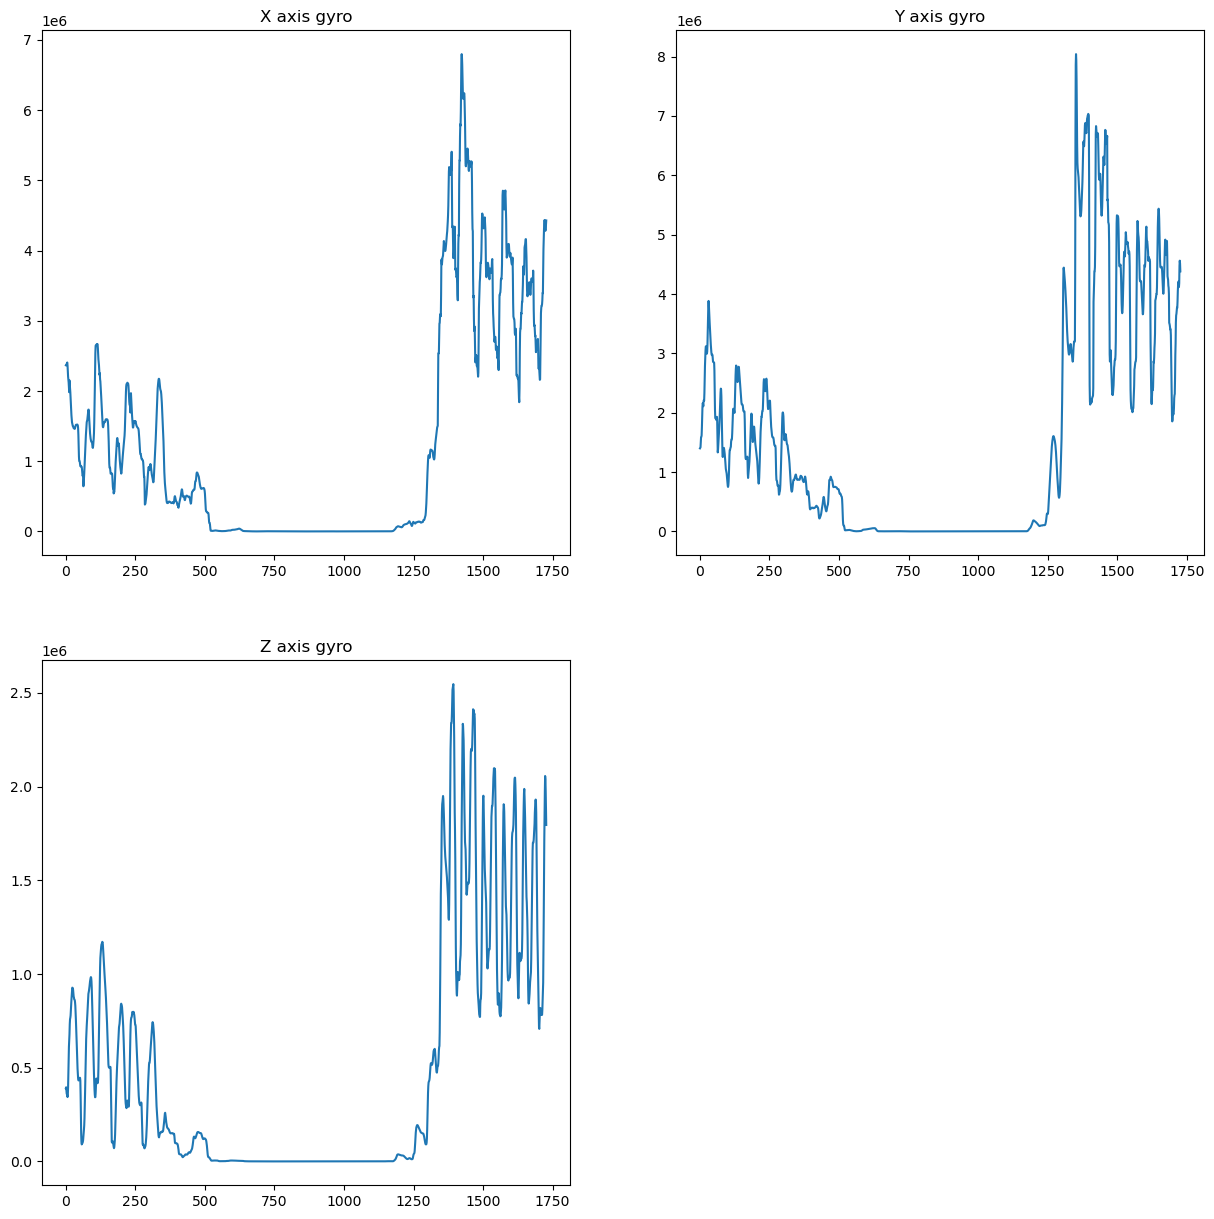

In [283]:
slice_of_motion_y_gyro = x_axis_gyro[focused_section2_start-pad:focused_section2_end+pad]
variances1 = localised_buffer_zone_variance_calculation(slice_of_motion_y_gyro,50)

slice_of_motion_y_gyro = y_axis_gyro[focused_section2_start-pad:focused_section2_end+pad]
variances2 = localised_buffer_zone_variance_calculation(slice_of_motion_y_gyro,50)

slice_of_motion_y_gyro = z_axis_gyro[focused_section2_start-pad:focused_section2_end+pad]
variances3 = localised_buffer_zone_variance_calculation(slice_of_motion_y_gyro,50)

fig,ax = plt.subplots(2,2,figsize=(15,15))
ax[0,0].plot(variances1)
ax[0,0].set_title("X axis gyro")
ax[0,1].plot(variances2)
ax[0,1].set_title("Y axis gyro")
ax[1,0].plot(variances3)
ax[1,0].set_title("Z axis gyro")
ax[1,1].axis("off")

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

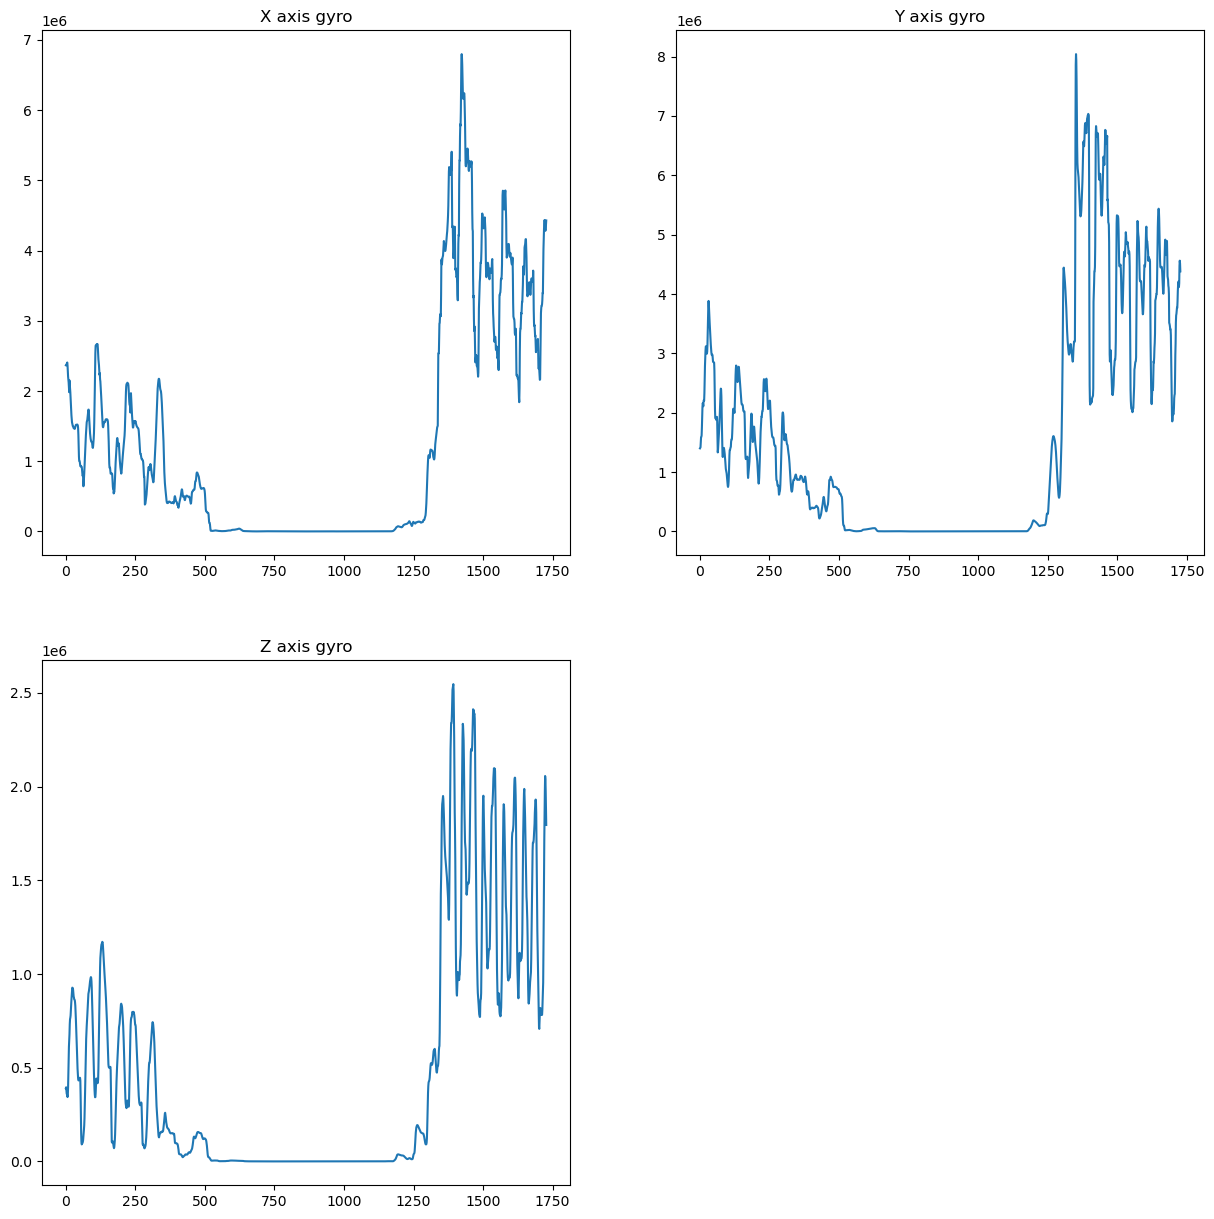

In [284]:
slice_of_motion_y_gyro = x_axis_gyro[focused_section2_start-pad:focused_section2_end+pad]
variances1 = localised_buffer_zone_variance_calculation(slice_of_motion_y_gyro,50)

slice_of_motion_y_gyro = y_axis_gyro[focused_section2_start-pad:focused_section2_end+pad]
variances2 = localised_buffer_zone_variance_calculation(slice_of_motion_y_gyro,50)

slice_of_motion_y_gyro = z_axis_gyro[focused_section2_start-pad:focused_section2_end+pad]
variances3 = localised_buffer_zone_variance_calculation(slice_of_motion_y_gyro,50)

fig,ax = plt.subplots(2,2,figsize=(15,15))
ax[0,0].plot(variances1)
ax[0,0].set_title("X axis gyro")
ax[0,1].plot(variances2)
ax[0,1].set_title("Y axis gyro")
ax[1,0].plot(variances3)
ax[1,0].set_title("Z axis gyro")
ax[1,1].axis("off")

You know what im not trynna think too hard right now... what I will do instead is just try to get as much as I can done with the 7300 eyeball number & it should be good enough & then later on I will come back around for this....

### Step 3 (Activity Annotations):

In [285]:
with open("a3_activity_annotations.csv",newline='') as f:
    reader = csv.reader(f)
    next(reader,None) # skip headers
    for row in reader:
        time_stamp = (row[0].split('='))[1]
        activity_label.append([float(time_stamp), row[-1], map_activity(row[-1])]) # just mapping an
        # activity i.e. jogging, standing etc. to every time stamp/interval
    
print(activity_label)

[[0.0, 'Walking', 1], [66.2, 'Standing', 0], [75.4, 'Walking', 1], [139.333333, 'Standing', 0], [146.733333, 'Jogging', 4], [191.4, 'Standing', 0], [197.2, 'Jogging', 4], [239.466667, 'Standing', 0], [244.6, 'Jogging', 4], [320.933333, 'Standing', 0], [328.0, 'Side-Step', 2], [345.066667, 'Standing', 0], [351.533333, 'Side-Step', 2], [371.333333, 'Standing', 0], [376.733333, 'Side-Step', 2], [396.533333, 'Standing', 0], [403.533333, 'Side-Step', 2], [422.4, 'Standing', 0], [426.933333, 'Jogging', 4], [466.866667, 'Standing', 0], [471.066667, 'Walking', 1], [538.133333, 'Standing', 0], [542.333333, 'Side-Step', 2], [561.066667, 'Standing', 0], [565.066667, 'Side-Step', 2], [584.866667, 'Standing', 0], [589.6, 'Running', 3], [614.8, 'Standing', 0], [619.8, 'Running', 3], [648.333333, 'Standing', 0], [653.533333, 'Running', 3], [678.466667, 'Standing', 0], [684.466667, 'Running', 3], [710.666667, 'Standing', 0]]


note interval:

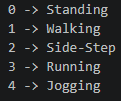

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

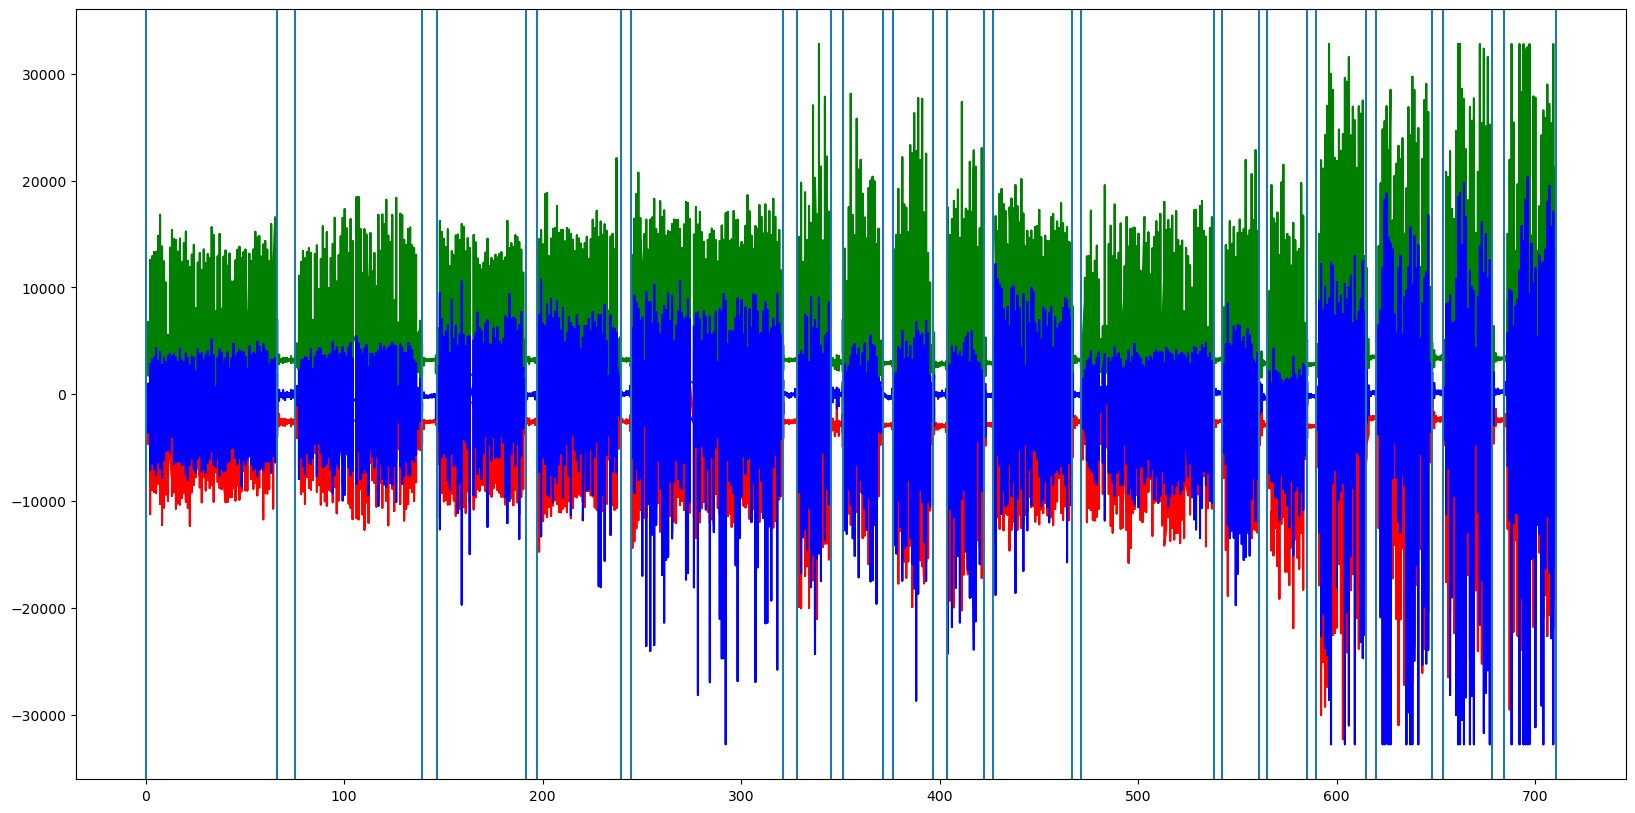

In [286]:
# creating activity time track for each data point within IMU timeseries:
activity_timeseries = []
activity_string_timeseries = []
activity_index = 0

video_end_timestamp = video_start_timestamp + 711
video_end_index = find_index_for_timestamp(video_end_timestamp,time_track)

# The time track segment we are interested in:
activity_video_time_track_segment = time_track[video_start_index:video_end_index]

# zeoring out time track segment so that it matches the video:
activity_video_time_track_segment = np.array(activity_video_time_track_segment)-video_start_timestamp

fig,ax = plt.subplots(figsize=(20,10))
ax.plot(activity_video_time_track_segment,x_axis_acceleration_data[video_start_index:video_end_index],
        color='r')
ax.plot(activity_video_time_track_segment,y_axis_acceleration_data[video_start_index:video_end_index],
        color='g')
ax.plot(activity_video_time_track_segment,z_axis_acceleration_data[video_start_index:video_end_index],
        color='b')

for imu_time_track_item in activity_video_time_track_segment:
    current_time = imu_time_track_item
    next_activity_timestamp = activity_label[activity_index+1][0]
    
    # here we need to move to the next activity in the annotations data if the current IMU data point
    # lies after the next annotation time stamp:
    if current_time > next_activity_timestamp:
        # move to next activity:
        activity_index += 1
        next_activity_timestamp = activity_label[activity_index+1][0]
        
    activity_timeseries.append(activity_label[activity_index][2])
    activity_string_timeseries.append(activity_label[activity_index][1])
    
print(activity_timeseries)
print(activity_string_timeseries)
print(activity_label)

# plotting location of activity transitions to sanity check the data
for act in np.array(list(zip(*activity_label)))[0,:]:
    ax.axvline(float(act))

It would be good to understand the balance of the data classes (i.e. the number of data points for each activity). This will inform us around the expected performance in a classifier algorithm. We will plot a histogram using the numeric activity code data. 

(array([ 8909., 19248., 11303., 10218., 19572.,     0.]),
 array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5]),
 <BarContainer object of 6 artists>)

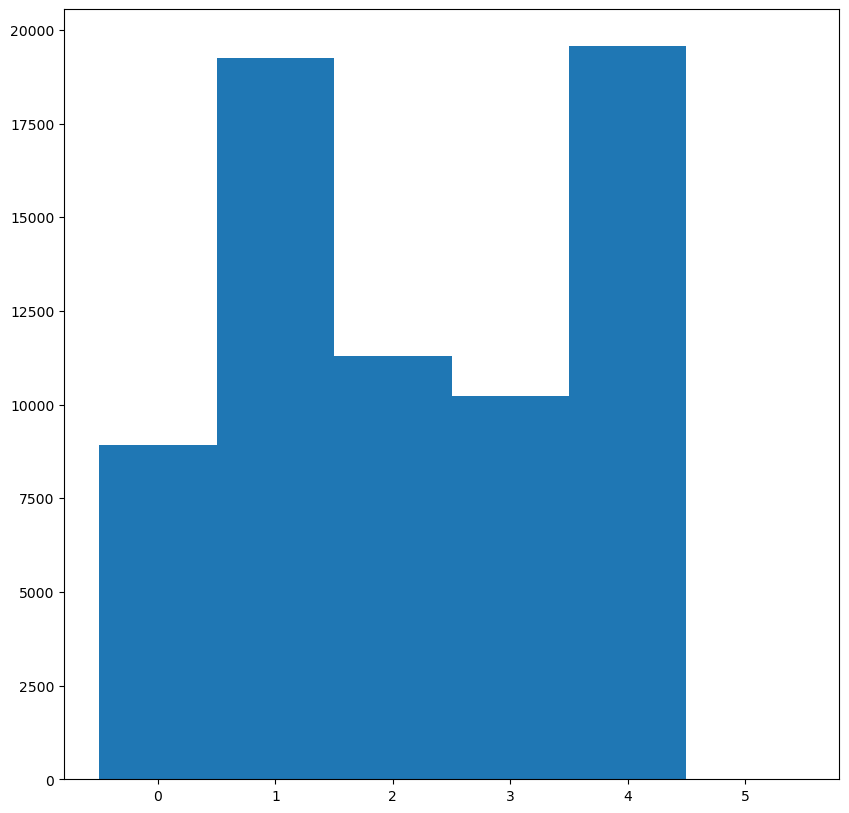

In [287]:
fig, ax = plt.subplots(figsize=(10,10))
ax.hist(activity_timeseries,bins=[-0.5,0.5,1.5,2.5,3.5,4.5,5.5])

In [288]:
# we are only interested in the video window...
x_axis_acceleration_data = x_axis_acceleration_data[video_start_index:video_end_index]
y_axis_acceleration_data = y_axis_acceleration_data[video_start_index:video_end_index]
z_axis_acceleration_data = z_axis_acceleration_data[video_start_index:video_end_index]
x_axis_gyro = x_axis_gyro[video_start_index:video_end_index]
y_axis_gyro = y_axis_gyro[video_start_index:video_end_index]
z_axis_gyro = z_axis_gyro[video_start_index:video_end_index]

### Step 4 (Calculating a Set of features from raw sensor data):

Having our classifiers just attempt to classify the action, i.e. running/jogging etc. just based of the raw IMU data is probably not going to give us very good results. Instead, to produce a classifier model that will be able to generalise well, we should probably calculate some features from the raw data that span multiple time steps. We can use the moving window approach to calculate a feature set for each second of data within the IMU dataset. As the task description lists, there are some potential features we are able to use here (in accordance with the task description claiming that these are best based upon experiments + literature);

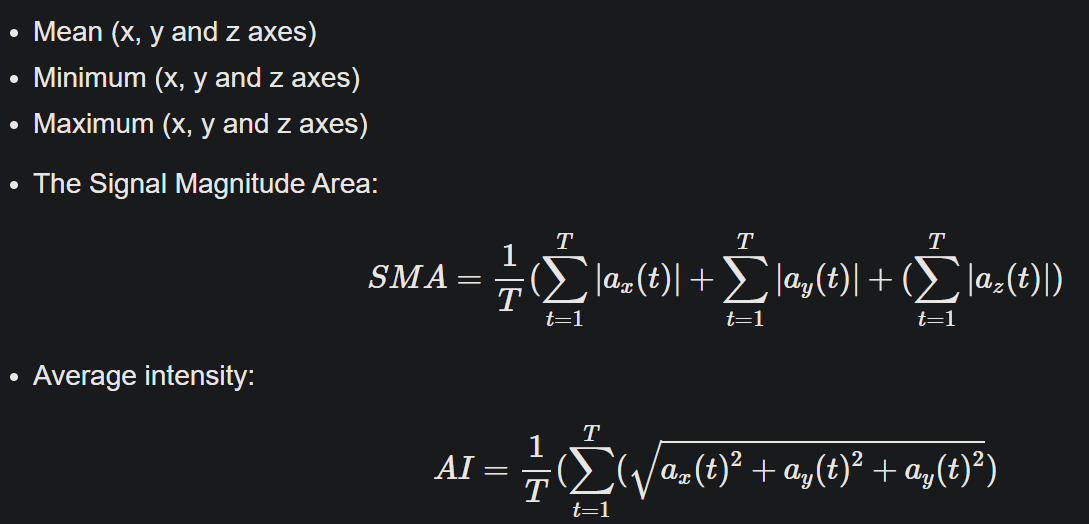

Note that in this, T is the num of time steps in a window of data (which is recommended to be 1 sec {the window of data of course}), the a values represent raw acceleration values within that window of data for the respective axis.... our SMA + AI are also able to be calculated using the raw gyroscope data as well....

## TO DO: Research additional features to try & get a better performance in our classifiers (later on). 

In [289]:
baseline_timestamp = time_track[video_start_index]
print(baseline_timestamp)
print(activity_video_time_track_segment[900:920]) # see this is all fractional... because we did - 66.2
# before... we need whole numbers because we loop over this
vid_stamps = time_track[video_start_index:video_end_index]
print(vid_stamps)
activity_video_time_track_segment = [t - baseline_timestamp for t in vid_stamps ]
print(f"**NEW ACTIVITY VIDEO TIME TRACK SEGMENT**:\n {activity_video_time_track_segment[900:920]}")

# So yes, we do loop through the entire video duration & calculating the features @ every moment etc..
print(f"START OF LOOP @: {activity_video_time_track_segment[0]}")
print(f"END OF LOOP @: {activity_video_time_track_segment[-1]}")

1598240221.0
[9.20000005 9.20000005 9.20000005 9.20000005 9.20000005 9.20000005
 9.20000005 9.20000005 9.20000005 9.20000005 9.20000005 9.20000005
 9.20000005 9.20000005 9.20000005 9.20000005 9.20000005 9.20000005
 9.20000005 9.20000005]
[1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 1598240221.0, 15982

Note that we have a problem where some data points are skipped/missed from the raw IMU data maybe because of like a slight error/lag during the SD Card write process. This will cause errors, so if we find a timestamp that is likely to cause errors, i.e. if say 105 time datapoint is missing, we can just go and find a bigger datapoint and return the index of that... so we skip over the datapoint we don't have...

In [290]:
def walk_through_list_to_find_index_after(target_time:int,time_list:list[int]):
    for i in range(len(time_list)):
        if time_list[i] >= target_time:
            return i
    return len(time_list) - 1 #the last index

In [291]:
feature_set = []
target_set = []
window_size = 1.0 # one second 

for t in range(int(activity_video_time_track_segment[0]),int(activity_video_time_track_segment[-1])):
    
    #index function to find the index of the first occurance of the data:
    window_start_index = walk_through_list_to_find_index_after(t,activity_video_time_track_segment)
    window_end_index = walk_through_list_to_find_index_after(t+window_size,
                                                             activity_video_time_track_segment)
    
    if window_start_index >= window_end_index:
        continue # we don't want to be trying to find e.g. the mean of 2 empty lists, at the very
        # end because of some missed datapoint... because then we'll get an error.... so just
        # if that does happen, skip it
    
    x_axis_acceleration_window = x_axis_acceleration_data[window_start_index:window_end_index]
    y_axis_acceleration_window = y_axis_acceleration_data[window_start_index:window_end_index]
    z_axis_acceleration_window = z_axis_acceleration_data[window_start_index:window_end_index]
    
    x_axis_gyro_window = x_axis_gyro[window_start_index:window_end_index]
    y_axis_gyro_window = y_axis_gyro[window_start_index:window_end_index]
    z_axis_gyro_window = z_axis_gyro[window_start_index:window_end_index]
    
    # the activity that is going to be assigned to the set of features for this window:
    activity_code = activity_timeseries[window_start_index]
    
    # Calculating mean of our different variables:
    x_axis_acceleration_mean = statistics.mean(x_axis_acceleration_window)
    y_axis_acceleration_mean = statistics.mean(y_axis_acceleration_window)
    z_axis_acceleration_mean = statistics.mean(z_axis_acceleration_window)
    
    x_axis_gyro_mean = statistics.mean(x_axis_gyro_window)
    y_axis_gyro_mean = statistics.mean(y_axis_gyro_window)
    z_axis_gyro_mean = statistics.mean(z_axis_gyro_window)
    
    # calculting the minimums from dataset:
    min_x_acceleration_data = min(x_axis_acceleration_window)
    min_y_acceleration_data = min(y_axis_acceleration_window)
    min_z_acceleration_data = min(z_axis_acceleration_window)
    
    min_x_gyro_data = min(x_axis_gyro_window)
    min_y_gyro_data = min(y_axis_gyro_window)
    min_z_gyro_data = min(z_axis_gyro_window)
    
    # maximums from raw data:
    max_x_acceleration_data = max(x_axis_acceleration_window)
    max_y_acceleration_data = max(y_axis_acceleration_window)
    max_z_acceleration_data = max(z_axis_acceleration_window)
        
    max_x_gyro_data = max(x_axis_gyro_window)
    max_y_gyro_data = max(y_axis_gyro_window)
    max_z_gyro_data = max(z_axis_gyro_window)
    
    x_axis_acceleration_abs_sum = 0
    y_axis_acceleration_abs_sum = 0
    z_axis_acceleration_abs_sum = 0
    
    x_axis_gyro_abs_sum = 0
    y_axis_gyro_abs_sum = 0
    z_axis_gyro_abs_sum = 0
    
    acceleration_sum_sequence = 0
    gyro_sum_sequence = 0
    
    # Loop to calculate values for SMA & AI:
    for i in range(0,len(x_axis_acceleration_window)):
        
        # adding up absolute values for SMA:
        x_axis_acceleration_abs_sum = x_axis_acceleration_abs_sum + abs(x_axis_acceleration_window[i])
        y_axis_acceleration_abs_sum = y_axis_acceleration_abs_sum + abs(y_axis_acceleration_window[i])
        z_axis_acceleration_abs_sum = z_axis_acceleration_abs_sum + abs(z_axis_acceleration_window[i])
        
        x_axis_gyro_abs_sum = x_axis_gyro_abs_sum + abs(x_axis_gyro_window[i])
        y_axis_gyro_abs_sum = y_axis_gyro_abs_sum + abs(y_axis_gyro_window[i])
        z_axis_gyro_abs_sum = z_axis_gyro_abs_sum + abs(z_axis_gyro_window[i])
        
        acceleration_sum_sequence = ((x_axis_acceleration_window[i]**2) + 
                                     (y_axis_acceleration_window[i]**2) + 
                                     (z_axis_acceleration_window[i]**2)) + acceleration_sum_sequence
        
        gyro_sum_sequence = ((x_axis_gyro_window[i]**2) + 
                             (y_axis_gyro_window[i]**2) + 
                             (z_axis_gyro_window[i]**2)) + gyro_sum_sequence
        
    # SMA:
    acceleration_sma = (x_axis_acceleration_abs_sum + y_axis_acceleration_abs_sum + 
                        z_axis_acceleration_abs_sum) / len(x_axis_acceleration_window)
    
    gyro_sma = (x_axis_gyro_abs_sum + y_axis_gyro_abs_sum + 
                z_axis_gyro_abs_sum) / len(x_axis_gyro_window)
    
    # AI:
    acceleration_avg_intensity = math.sqrt(acceleration_sum_sequence)/len(x_axis_acceleration_window)
    gyro_avg_intensity = math.sqrt(gyro_sum_sequence)/len(x_axis_acceleration_window)
    
    mean_data = (x_axis_acceleration_mean,y_axis_acceleration_mean,z_axis_acceleration_mean,
    x_axis_gyro_mean,y_axis_gyro_mean,z_axis_gyro_mean)
    
    max_data = (max_x_acceleration_data,max_y_acceleration_data,max_z_acceleration_data, 
    max_x_gyro_data,max_y_gyro_data,max_z_gyro_data)
    
    min_data = (min_x_acceleration_data,min_y_acceleration_data,min_z_acceleration_data, 
    min_x_gyro_data,min_y_gyro_data,min_z_gyro_data)
    
    sma_data = acceleration_sma,gyro_sma
    
    avg_intensity_data = acceleration_avg_intensity,gyro_avg_intensity
    
    feature_row = [mean_data, \
                   max_data, \
                   min_data, \
                   sma_data,avg_intensity_data]
    
    # and now our data is prepped:
    feature_set.append(feature_row)
    target_set.append(activity_code)
    
print(f"FEATURE SET LEN: {len(feature_set)}")
print(f"TARGET SET LEN: {len(target_set)}")
print(f"FEATURE SET PREVIEW: {feature_set[20:35]}")
print(f"TARGET SET PREVIEW: {target_set[20:35]}")


FEATURE SET LEN: 707
TARGET SET LEN: 707
FEATURE SET PREVIEW: [[(-2689.38, 3206.56, -365.92, 71.75, -3.34, -161.43), (-302.0, 15228.0, 3824.0, 2308.0, 3706.0, 1223.0), (-10048.0, -2180.0, -7456.0, -4022.0, -4076.0, -1682.0), (7066.5, 3342.62), (535.0580009681194, 237.10272541664298)], [(-2692.56, 3267.26, -368.72, 157.42, -10.84, -104.55), (-236.0, 12496.0, 3348.0, 2256.0, 3788.0, 1339.0), (-10630.0, -2634.0, -8028.0, -3114.0, -5418.0, -2009.0), (7115.34, 3364.15), (540.1755370247713, 240.07544001834088)], [(-2679.0, 3243.08, -375.54, 132.57, 33.25, -72.2), (-338.0, 11910.0, 2686.0, 2242.0, 3471.0, 1740.0), (-12314.0, -676.0, -6590.0, -3127.0, -2846.0, -1367.0), (6912.14, 3203.98), (523.7068542610455, 221.71126583915395)], [(-2619.88, 3298.64, -479.98, 51.53, 85.44, -103.01), (-452.0, 13072.0, 3516.0, 2019.0, 2923.0, 1388.0), (-9190.0, -1354.0, -5994.0, -2851.0, -4142.0, -1433.0), (6958.54, 3343.52), (520.9449564013457, 229.62126208171577)], [(-2789.098901098901, 3388.4615384615386, -5

So overall I don't think we're loosing too many datapoints....

### Applying ML Classifiers

Use sgd, random forest, Adaboost as my 3 ML algorithms... to compare them we can just make use of like confusion matrices, f1, ROC/AUC etc... & hyperparameter 

#### SGD Classifier

In [292]:
from sklearn.model_selection import train_test_split,cross_val_predict
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler,label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix,recall_score,precision_score,f1_score
from sklearn.metrics import ConfusionMatrixDisplay,roc_curve,auc

go into detail about this error because for our feature set which has like 5 tuples, for each second of the window: we have 3 tuples with length 6 i.e. the mean tuple which contains the mean values of all the x,y,z acceleration & gyro of raw sensor readings during the 1 sec window, the max & min & we have another 2 tuples for the SMA/AI that contain just the 2 elements, i.e. for SMA, acceleration sma + gyro sma & similarly for AI, it would be acceleration AI + gyro AI....
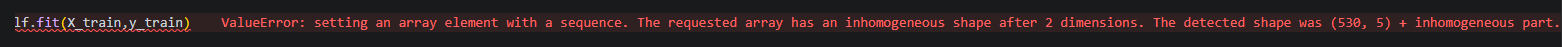

But apparently, numpy & sklearn have problems with our feature_set which is a list of lists with tuples of these different sizes.. They want a flat, uniform 2d numerical matrix with like rows & columns, but we're feeding it rows with like nested groups of different dimensions...

So I guess the only way we could go about this is having the tuples into like a 2d array (list of lists) or something...

In [293]:
two_dim_feature_set = []

for one_sec_window in feature_set:
    flattened_window_sample = []
    for sub_tuple in one_sec_window:
        flattened_window_sample.extend(sub_tuple) # extend over append here, as we need to iterate over the tuple 
    two_dim_feature_set.append(flattened_window_sample)

print(two_dim_feature_set[:10])

[[-2509.54, 2991.06, -858.64, 109.34, 397.5, -186.32, -1314.0, 4694.0, 368.0, 1789.0, 2811.0, 217.0, -3742.0, 1692.0, -3510.0, -1206.0, -86.0, -1086.0, 6370.8, 1133.1, 417.7114238322912, 108.57176060099606], [-2703.36, 3299.4, -318.74, 188.04, -120.14, -54.69, -650.0, 6784.0, 994.0, 2548.0, 3042.0, 895.0, -4628.0, 1786.0, -3576.0, -1334.0, -2889.0, -1814.0, 6675.9, 2620.39, 459.70963574847985, 196.06459930339287], [-2706.4, 3284.92, -480.52, 24.89, -203.91, 41.65, 32.0, 12562.0, 2822.0, 2076.0, 3959.0, 1289.0, -11210.0, -1244.0, -7110.0, -2361.0, -4045.0, -1564.0, 7095.0, 3184.83, 530.3769384126726, 225.07128804003412], [-2678.989010989011, 2999.6703296703295, -464.6373626373626, -261.1208791208791, -471.72527472527474, 120.87912087912088, -592.0, 12910.0, 3198.0, 1857.0, 2942.0, 1110.0, -8976.0, -1376.0, -6478.0, -3004.0, -4256.0, -1381.0, 6868.483516483517, 2798.252747252747, 541.0387706388332, 213.1116348129445], [-2692.7755102040815, 2993.918367346939, -468.265306122449, -188.60204

Now we should have every like one second window as one list in this list of lists... and every one second window will contain the 6 + 6 + 6 + 2 + 2 = 22 features...

CV Train Recall: [0.90625    0.94285714 0.89156627 0.9047619  0.94968553]
CV Train Precision: [0.86567164 0.96350365 0.87058824 0.89411765 0.96794872]
CV Train F1 Score: [0.88549618 0.95306859 0.88095238 0.89940828 0.95873016]
Test Recall: [0.88888889 0.92857143 0.87096774 0.95       0.95348837]
Test Precision: [0.88888889 0.92857143 0.93103448 0.86363636 0.95348837]
Test F1 Score: [0.88888889 0.92857143 0.9        0.9047619  0.95348837]


Text(0.5, 1.0, 'Classifier performance on test set')

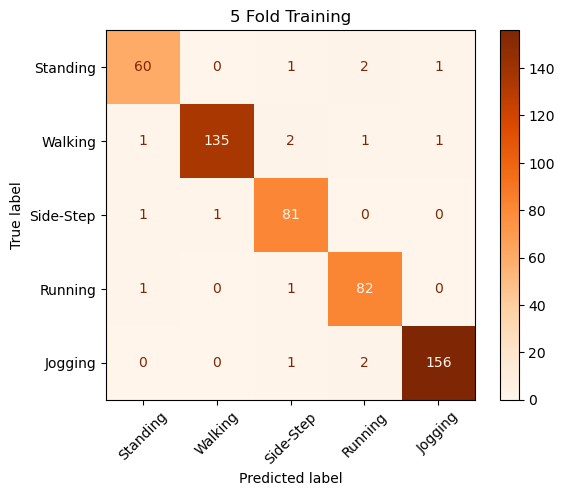

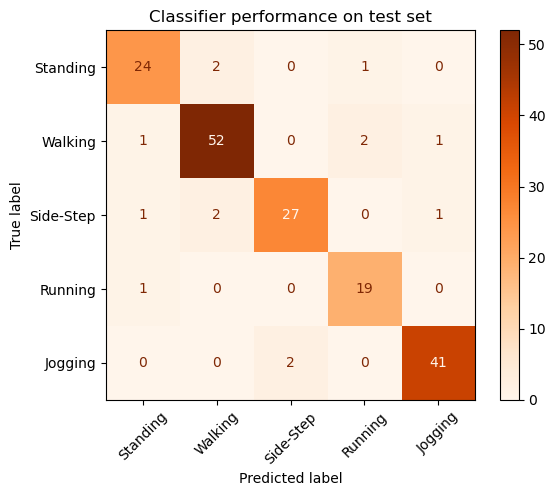

In [294]:
X_train,X_test,y_train,y_test = train_test_split(two_dim_feature_set,target_set,random_state=0)

# including hyperparams... I think; wikipedia mentions: 
# In machine learning, a hyperparameter is a parameter that can be set in order to define any
# configurable part of a model's learning process. Hyperparameters can be classified as either
# model hyperparameters (such as the topology and size of a neural network) or algorithm 
# hyperparameters (such as the learning rate and the batch size of an optimizer). 
# These are named hyperparameters in contrast to parameters, which are characteristics that the 
# model learns from the data.
# & so we are directly changing the learning rate with alpha + like batch size etc...
# Just go over the sources & write out a detailed explanation for the hyperparams for SGD:
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html
# https://medium.com/@juanc.olamendy/sgdclassifier-the-powerhouse-for-large-scale-classification-9ae2369d57fb
# https://www.geeksforgeeks.org/python/stochastic-gradient-descent-classifier/
# https://en.wikipedia.org/wiki/Hyperparameter_(machine_learning)
# also worth having a look at this as well:
# https://www.geeksforgeeks.org/machine-learning/difference-between-batch-gradient-descent-and-stochastic-gradient-descent/
# seems as though I keep going deeper & deeper to find more interesting things; Look at the 
# mini-batch here: https://medium.com/@juanc.olamendy/mini-batch-gradient-descent-optimizing-machine-learning-98ef238c5225
# https://www.kaggle.com/code/eissaislam/linear-regression-using-batch-gradient-descent
sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(loss='log_loss',
                                                                     penalty='l2',alpha=0.00001,
                                                                     random_state=0))])

sgd_clf.fit(X_train,y_train)

# run predictions for 5 fold cv:
y_pred = cross_val_predict(sgd_clf,X_train,y_train,cv=5)

# predictions for test set:
y_test_pred = sgd_clf.predict(X_test)

conf_matrix_train = confusion_matrix(y_train,y_pred)
conf_matrix_test = confusion_matrix(y_test,y_test_pred)

# printing out recall, precision & f1 scores...
# just note that there is a value for each calss:
print("CV Train Recall:", recall_score(y_train,y_pred,average=None))
print("CV Train Precision:",precision_score(y_train,y_pred,average=None))
print("CV Train F1 Score:",f1_score(y_train,y_pred,average=None))

# Test
print("Test Recall:",recall_score(y_test,y_test_pred,average=None))
print("Test Precision:",precision_score(y_test,y_test_pred,average=None))
print("Test F1 Score:",f1_score(y_test,y_test_pred,average=None))

# plotting confusion matrices:
fig,ax = plt.subplots()
disp = ConfusionMatrixDisplay.from_estimator(sgd_clf,X_train,y_train,
                                             display_labels=['Standing','Walking','Side-Step','Running','Jogging'],
                                             cmap=plt.cm.Oranges,ax=ax)

# rotating the labels so that they are able to be read:
for tick in ax.get_xticklabels():
    tick.set_rotation(45)

ax.set_title('5 Fold Training')

fig,ax = plt.subplots()
disp = ConfusionMatrixDisplay.from_estimator(sgd_clf,X_test,y_test,
                                             display_labels=['Standing','Walking','Side-Step','Running','Jogging'],
                                             cmap=plt.cm.Oranges,ax=ax)

for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    
ax.set_title("Classifier performance on test set")

Text(0.5, 1.0, 'Roc Curves for our 5 classes to evalute SGDClassifier')

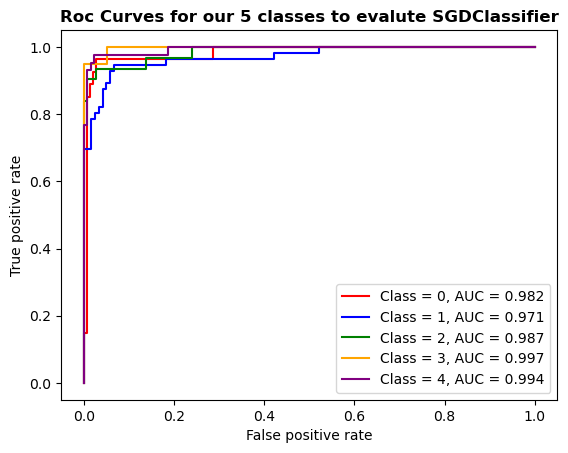

In [295]:
# just visualising the ROC curves + learnt decision boundaries w/ training data:

y_scores = sgd_clf.decision_function(X_test)

y_test_bin = label_binarize(y_test,classes=[0,1,2,3,4])

fpr = dict()
tpr = dict()
roc_auc = dict()

fig,ax = plt.subplots()
colours_for_curves = ['red','blue','green','orange','purple']

for i in range(5):
    fpr[i],tpr[i],_ = roc_curve(y_test_bin[:,i],y_scores[:,i])
    
    roc_auc[i] = auc(fpr[i],tpr[i])
    
    ax.plot(fpr[i],tpr[i],color=colours_for_curves[i],
            label=(f"Class = {i}, AUC = {roc_auc[i]:.3f}"))

plt.legend(loc=4)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("Roc Curves for our 5 classes to evalute SGDClassifier",fontweight="bold")


Well our classifier was trained on the 22 features, & we can't really just visualise 22d data... So let's just use the first two features... And even then just note that the decision boundary will represent like if 20 features were average values, and we only looked at the 2 selected features then this is what decision boundaries look like....

### TODO: So im thinking maybe we can replicate like something we did in at2 to select the best 2 features that would be able to give us the best decision boundary;

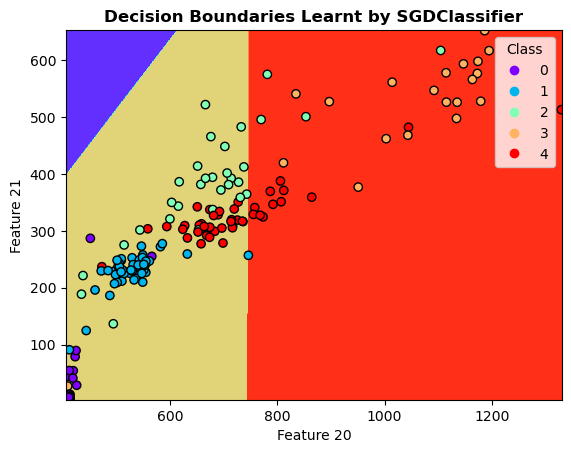

In [296]:
# note that our X_test etc. is a python list, so we can't do like X_test.min() because we'll get an err
# so we need to convert to np array first:
X_test = np.array(X_test)
X_train = np.array(X_train)
y_test = np.array(y_test)
y_train = np.array(y_train)

x_feature = 20
y_feature = 21

x_min, x_max = X_test[:,x_feature].min() - 1, X_test[:,x_feature].max() + 1
y_min, y_max = X_test[:,y_feature].min() - 1, X_test[:,y_feature].max() + 1

xx,yy = np.meshgrid(np.linspace(x_min,x_max,500),np.linspace(y_min,y_max,500))

# creating 22 feature vector for all points in grid.... we first just start by setting every feature to its mean val:
grid_points = np.tile(X_train.mean(axis=0), (xx.ravel().shape[0],1))

grid_points[:,x_feature] = xx.ravel()
grid_points[:,y_feature] = yy.ravel()

grid_predictions = sgd_clf.predict(grid_points)

grid_predictions = grid_predictions.reshape(xx.shape)

fig,ax = plt.subplots()

ax.contourf(xx,yy,grid_predictions,cmap="rainbow")

scatter_points = ax.scatter(X_test[:,x_feature],X_test[:,y_feature],c=y_test,cmap="rainbow",edgecolor="black")
ax.legend(*scatter_points.legend_elements(),title="Class")

ax.set_xlabel(f"Feature {x_feature}")
ax.set_ylabel(f"Feature {y_feature}")

ax.set_title("Decision Boundaries Learnt by SGDClassifier", fontweight="bold")
plt.show()

#### Random Forest

hyperparam for this could probably just be like max_samples/depth or samples split or something.... but look more into it

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rand_forest_clf = RandomForestClassifier(random_state=0)
rand_forest_clf.fit(X_train,y_train)



#### AdaBoost